# LSTM (Long Short Term Memory)

## Why do we need LSTM?

RNN have vanishing and exploding gradient problem with long term dependencies

Examle: I grew up in India ... many words ... I speak fluent _____.

RNN strugels to answer

but LSTM was designed to provide a better mechanism for controlling what information should be remembered, forgotten and exposed to the next layer.

## Key Idea

LSTM introduces a seperate memory called the cell state C_t

LSTM has two states:
1. h_t (hidden state)
    - output by the LSTM

2. c_t (cell state)
    - the long term memory

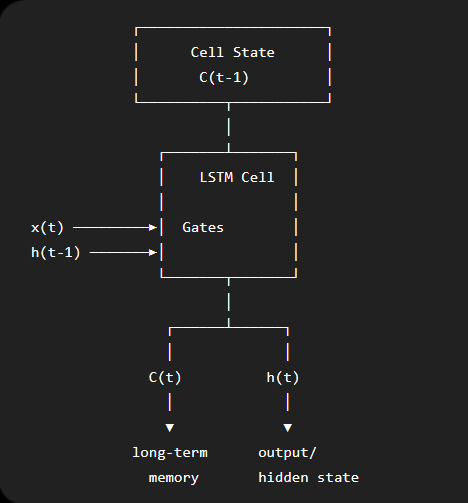

## The LSTM Cell
3 Gate and 1 candidate memory

### The Three Gate

Value Range 0 to 1 (uses sigmoid)

1. Input Gate
    - what info should i store
2. Forget Gate
    - what info should i remove from prev cell state
3. output Gate
    - what part of my internal memory should i expose as the hidden state

### The candidate memory

Value Range -1 to 1 (uses tanh)

1. candidiate cell memory
    - It contains potential new info

## How it works?

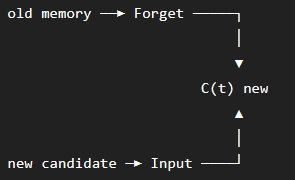

Forget: What old information should I remove?

Candidate: What new information could I create?

Input: How much of that new information should I store?

Cell state: What is my updated memory?

Output: What part of my memory should I expose?

In [96]:
import numpy as np

In [97]:
# Many-to-one LSTM 
X = [ [1.0, 0.5], [0.5, 1.0], [1.0, 1.5], [1.5, 1.0] ] 
X = np.array(X) 

# Class index 
target = 1 
 
X

array([[1. , 0.5],
       [0.5, 1. ],
       [1. , 1.5],
       [1.5, 1. ]])

Here:

Number of timesteps = 4

Input size          = 2

Therefore:

$$
X \in \mathbb{R}^{4\times2}
$$

# Parameters

Our LSTM will have:

input_size  = 2

hidden_size = 2

output_size = 2

The LSTM has four transformations:

1. Forget gate

2. Input gate

3. Candidate memory

4. Output gate

Each transformation receives:

$$
[h_{t-1},x_t]
$$

The size of this vector is:

$$
hidden_{size} + input_{size}
$$

Therefore:

$$
2+2=4
$$

Each weight matrix therefore has shape:

$$
(2,4)
$$

In [98]:
input_size = 2 
hidden_size = 2 
output_size = 2 

# Initial hidden state 
 
h = np.zeros(hidden_size) 

# Initial cell state 

C = np.zeros(hidden_size)

# Forget Gate
Wf = np.array([ [0.1, 0.2, 0.3, 0.4], [0.5, 0.6, 0.7, 0.8] ]) # weight

bf = np.array([0.1, 0.1]) # bais

# Input Gate
Wi = np.array([ [0.2, 0.1, 0.4, 0.3], [0.6, 0.5, 0.8, 0.7] ]) # weight

bi = np.array([0.1, 0.1]) # bais

# Candidate Cell State
Wc = np.array([ [0.3, 0.2, 0.1, 0.4], [0.7, 0.6, 0.5, 0.8] ]) # weight

bc = np.array([0.0, 0.0]) # bais

# Output Gate
Wo = np.array([ [0.4, 0.3, 0.2, 0.1], [0.8, 0.7, 0.6, 0.5] ]) # weight

bo = np.array([0.1, 0.1]) # bais

# Output Layer

Why = np.array([ [0.5, 0.3], [0.2, 0.4] ]) # weight

by = np.array([0.1, 0.2]) # bais

# Learning rate
lr = 0.01

# Activation Functions

In [99]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

LSTM Forward Pass

The complete LSTM equations are:

Forget Gate

$$
f_t =
\sigma(W_f[h_{t-1},x_t]+b_f)
$$

The forget gate decides how much previous memory should remain.

Input Gate

$$
i_t =
\sigma(W_i[h_{t-1},x_t]+b_i)
$$

The input gate decides how much new information should enter the cell state.

Candidate Memory

$$
\tilde C_t =
\tanh(W_C[h_{t-1},x_t]+b_C)
$$

The candidate contains potential new information.

Cell State

$$
C_t =
f_t\odot C_{t-1}
+
i_t\odot\tilde C_t
$$

This is the main memory update.

Output Gate

$$
o_t =
\sigma(W_o[h_{t-1},x_t]+b_o)
$$

The output gate decides how much of the current memory should be exposed.

Hidden State

$$
h_t =
o_t\odot\tanh(C_t)
$$

In [100]:
def LSTM_forward(X, h, C, Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by):

    # Store states
    hidden_states = []
    cell_states = []

    forget_gates = []
    input_gates = []
    candidate_states = []
    output_gates = []

    # Initial states
    hidden_states.append(h.copy())
    cell_states.append(C.copy())


    # process sequence
    for t in range(len(X)):

        x_t = X[t]

        # concatenate previous hidden state and current input

        z = np.concatenate([h, x_t])

        # Forget Gate

        af = Wf @ z + bf

        f = sigmoid(af)


        # Input Gate

        ai = Wi @ z + bi

        i = sigmoid(ai)

        # Candidate cell state

        ac = Wc @ z + bc

        candidate = tanh(ac)

        # cell state

        C = (f * C) + (i * candidate)

        # output Gate

        ao = Wo @ z + bo

        o = sigmoid(ao)

        # Hidden state

        h = o * tanh(C)

        hidden_states.append(h.copy())
        cell_states.append(C.copy())
    
        forget_gates.append(f.copy())
        input_gates.append(i.copy())
        candidate_states.append(candidate.copy())
        output_gates.append(o.copy())

    # Output Layer

    z_y = (Why @ h) + by

    def softmax(z):
        max_z = np.exp(z - np.max(z))

        return max_z / np.sum(max_z)

    y = softmax(z_y)

    cache = {
        "hidden_states" : hidden_states,
        "cell_states" : cell_states,
        "forget_gates" : forget_gates,
        "input_gates" : input_gates,
        "candidate_states" : candidate_states,
        "output_gates" : output_gates
    }

    return y, cache

In [101]:
y, cache = LSTM_forward(X, h, C, Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by)

print("Final prediction:", y)

Final prediction: [0.49738349 0.50261651]


# Loss Function

In [102]:
def CrossEntropyLoss(y, target):
    return - np.log(y[target])


loss = CrossEntropyLoss(y, target)


loss

np.float64(0.6879277973556128)

# BPTT (BackPropagation Through Time)

This is where LSTM becomes different from the simple RNN.

In a simple RNN, we mainly propagate the gradient through the hidden state:

$$
\frac{\partial L}{\partial h_t}
$$

But an LSTM has an additional recurrent memory state called the cell state.

Therefore, during backpropagation through time, we must propagate two gradients:

$$
\frac{\partial L}{\partial h_t}
$$

and

$$
\frac{\partial L}{\partial C_t}
$$

We therefore maintain:

```text
dh_next
dc_next
```

where:

* `dh_next` = gradient arriving from the future hidden state
* `dc_next` = gradient arriving from the future cell state

---

# 1. Output Layer Backward Pass

Our output layer is:

$$
z_y = W_{hy}h_T + b_y
$$

The output probabilities are obtained using Softmax:

$$
y = \operatorname{softmax}(z_y)
$$

When Softmax is combined with Cross Entropy Loss, the gradient simplifies to:

$$
\boxed{
\frac{\partial L}{\partial z_y}
=
y-y_{\text{target}}
}
$$

where $y_{\text{target}}$ is the one-hot encoded target vector.

The gradient with respect to the output weights is:

$$
\boxed{
\frac{\partial L}{\partial W_{hy}}
=
\frac{\partial L}{\partial z_y}
h_T^T
}
$$

The gradient with respect to the output bias is:

$$
\boxed{
\frac{\partial L}{\partial b_y}
=
\frac{\partial L}{\partial z_y}
}
$$

The gradient flowing into the final hidden state is:

$$
\boxed{
\frac{\partial L}{\partial h_T}
=
W_{hy}^T
\frac{\partial L}{\partial z_y}
}
$$

This becomes the initial `dh_next` for the LSTM backward pass.

---

# 2. Important LSTM Backward Equations

At timestep $t$, the LSTM receives a gradient from the future hidden state:

$$
dh_{\text{next}}
$$

and a gradient from the future cell state:

$$
dc_{\text{next}}
$$

For simplicity, during the calculations at the current timestep we call them:

$$
dh
$$

and

$$
dc
$$

The backward pass then calculates the gradients for:

* Output gate
* Cell state
* Forget gate
* Input gate
* Candidate
* Previous hidden state
* Previous cell state
* All trainable weights and biases

---

# 3. Output Gate Backward

The hidden state is:

it means element-wise multiplication (also called Hadamard product).

$$
h_t
=
o_t
\odot
\tanh(C_t)
$$

We first calculate the gradient with respect to the output gate.

Using the chain rule:

$$
\boxed{
do_t
=
dh
\odot
\tanh(C_t)
}
$$

The output gate uses the sigmoid activation:

$$
o_t=\sigma(a_o)
$$

The derivative of sigmoid is:

$$
\boxed{
\sigma'(x)
=
\sigma(x)(1-\sigma(x))
}
$$

Therefore:

$$
\boxed{
da_o
=
do_t
\odot
o_t
\odot
(1-o_t)
}
$$

where:

* $do_t$ = gradient with respect to output gate
* $da_o$ = gradient with respect to the output gate's pre-activation

---

# 4. Gradient Through the Cell State

The hidden state is:

$$
h_t
=
o_t
\odot
\tanh(C_t)
$$

The cell state therefore receives a gradient from the hidden state:

$$
\boxed{
dc_{\text{from hidden}}
=
dh
\odot
o_t
\odot
\left(1-\tanh^2(C_t)\right)
}
$$

However, the cell state also receives a gradient from the **future cell state**.

Therefore the total gradient flowing into the current cell state is:

$$
\boxed{
dc
=
dc_{\text{next}}
+
dh
\odot
o_t
\odot
\left(1-\tanh^2(C_t)\right)
}
$$

This is one of the most important equations in LSTM backpropagation.

The reason is that the cell state has its own recurrent pathway:

$$
C_t
\rightarrow
C_{t-1}
\rightarrow
C_{t-2}
\rightarrow
\cdots
$$

---

# 5. Forget Gate Backward

The cell-state equation is:

$$
C_t
=
f_t
\odot
C_{t-1}
+
i_t
\odot
\tilde C_t
$$

For the forget-gate branch:

$$
f_t
\odot
C_{t-1}
$$

Therefore:

$$
\boxed{
df_t
=
dc
\odot
C_{t-1}
}
$$

The forget gate uses sigmoid:

$$
f_t=\sigma(a_f)
$$

Therefore:

$$
\boxed{
da_f
=
df_t
\odot
f_t
\odot
(1-f_t)
}
$$

---

# 6. Input Gate Backward

The input-gate branch is:

$$
i_t
\odot
\tilde C_t
$$

Therefore:

$$
\boxed{
di_t
=
dc
\odot
\tilde C_t
}
$$

The input gate uses sigmoid:

$$
i_t=\sigma(a_i)
$$

Therefore:

$$
\boxed{
da_i
=
di_t
\odot
i_t
\odot
(1-i_t)
}
$$

---

# 7. Candidate Backward

The candidate state is:

$$
\tilde C_t
=
\tanh(a_C)
$$

The candidate contributes to the cell state through:

$$
i_t
\odot
\tilde C_t
$$

Therefore:

$$
\boxed{
d\tilde C_t
=
dc
\odot
i_t
}
$$

Since:

$$
\frac{d}{dx}\tanh(x)
=
1-\tanh^2(x)
$$

and:

$$
\tilde C_t=\tanh(a_C)
$$

we get:

$$
\boxed{
da_C
=
d\tilde C_t
\odot
(1-\tilde C_t^2)
}
$$

---

# 8. Gradient to Previous Cell State

The cell-state equation is:

$$
C_t
=
f_t
\odot
C_{t-1}
+
i_t
\odot
\tilde C_t
$$

The only direct dependency on the previous cell state is:

$$
f_t
\odot
C_{t-1}
$$

Therefore:

$$
\boxed{
dc_{t-1}
=
dc_t
\odot
f_t
}
$$

In our implementation:

```python
dc_next = dc * f
```

This is the important memory pathway of the LSTM.

If:

$$
f_t\approx1
$$

then:

$$
dc_{t-1}\approx dc_t
$$

Therefore the gradient can pass through the cell-state pathway with relatively little attenuation.

---

# 9. Gradient to the Concatenated Vector

All four transformations use the same concatenated vector:

$$
z_t
=
[h_{t-1},x_t]
$$

The four pre-activations are:

$$
a_f=W_fz_t+b_f
$$

$$
a_i=W_iz_t+b_i
$$

$$
a_C=W_Cz_t+b_C
$$

$$
a_o=W_oz_t+b_o
$$

Therefore, $z_t$ receives gradients from all four branches.

The total gradient is:

$$
\boxed{
dz_t
=
W_f^Tda_f
+
W_i^Tda_i
+
W_C^Tda_C
+
W_o^Tda_o
}
$$

This combines the gradients from:

```text
Forget Gate
     │
Input Gate
     │
Candidate
     │
Output Gate
     │
     ▼
   dz_t
```

---

# 10. Splitting the Concatenated Gradient

Recall:

$$
z_t
=
[h_{t-1},x_t]
$$

For example, if:

```text
hidden_size = 2
input_size  = 2
```

then:

$$
z_t
=
[h_1,h_2,x_1,x_2]
$$

Therefore:

$$
dz_t
=
[dh_1,dh_2,dx_1,dx_2]
$$

We split it into:

$$
\boxed{
dh_{t-1}
=
dz_t[:H]
}
$$

and:

$$
\boxed{
dx_t
=
dz_t[H:]
}
$$

where $H$ is the hidden size.

In NumPy:

```python
dh_prev = dz[:hidden_size]

dx = dz[hidden_size:]
```

We don't need `dx` for parameter optimization because the input sequence $X$ is not a trainable parameter.

The important value that must be passed to the previous timestep is:

```python
dh_next = dh_prev
```

---

# 11. Weight Gradients

Every LSTM gate has the general form:

$$
a=Wz+b
$$

Suppose:

$$
a=Wz+b
$$

and we know:

$$
da=\frac{\partial L}{\partial a}
$$

Then the weight gradient is:

$$
\boxed{
dW
=
da\otimes z
}
$$

where $\otimes$ represents the outer product.

The bias gradient is:

$$
\boxed{
db=da
}
$$

---

# 12. Forget Gate Weight Gradients

The forget gate is:

$$
a_f=W_fz+b_f
$$

Therefore:

$$
\boxed{
dW_f
=
da_f\otimes z_t
}
$$

and:

$$
\boxed{
db_f
=
da_f
}
$$

In NumPy:

```python
dWf += np.outer(daf, z)

dbf += daf
```

We use `+=` because the same weights are used at every timestep.

Therefore the final gradient is the sum of the gradients from all timesteps.

---

# 13. Input Gate Weight Gradients

The input gate is:

$$
a_i=W_iz+b_i
$$

Therefore:

$$
\boxed{
dW_i
=
da_i\otimes z_t
}
$$

and:

$$
\boxed{
db_i
=
da_i
}
$$

In NumPy:

```python
dWi += np.outer(dai, z)

dbi += dai
```

---

# 14. Candidate Weight Gradients

The candidate is:

$$
a_C=W_Cz+b_C
$$

Therefore:

$$
\boxed{
dW_C
=
da_C\otimes z_t
}
$$

and:

$$
\boxed{
db_C
=
da_C
}
$$

In NumPy:

```python
dWc += np.outer(dac, z)

dbc += dac
```

---

# 15. Output Gate Weight Gradients

The output gate is:

$$
a_o=W_oz+b_o
$$

Therefore:

$$
\boxed{
dW_o
=
da_o\otimes z_t
}
$$

and:

$$
\boxed{
db_o
=
da_o
}
$$

In NumPy:

```python
dWo += np.outer(dao, z)

dbo += dao
```

---

The cell-state pathway is the key mechanism that allows LSTM to preserve useful information across longer sequences.



In [103]:
def LSTM_backward(X, y_true, cache, y_pred, Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by, hidden_size):

    # input
    h_final = cache["hidden_states"][-1]

    dz_y = y_pred - y_true

    dWhy = np.outer(dz_y, h_final)
    dby = dz_y.copy()

    dh_next = Why.T @ dz_y

    dc_next = np.zeros(hidden_size)


    # input
    dWf = np.zeros_like(Wf)
    dbf = np.zeros_like(bf)

    dWi = np.zeros_like(Wi)
    dbi = np.zeros_like(bi)

    dWc = np.zeros_like(Wc)
    dbc = np.zeros_like(bc)

    dWo = np.zeros_like(Wo)
    dbo = np.zeros_like(bo)


    # input
    for t in reversed(range(len(X))):

        # input
        f = cache["forget_gates"][t]

        i = cache["input_gates"][t]

        candidate = cache["candidate_states"][t]

        o = cache["output_gates"][t]


        # input
        C = cache["cell_states"][t + 1]

        C_prev = cache["cell_states"][t]

        h_prev = cache["hidden_states"][t]


        # input
        x_t = X[t]

        z = np.concatenate([h_prev, x_t])


        # input
        do = dh_next * np.tanh(C)

        dao = do * o * (1 - o)


        # input
        dc = (
            dc_next
            + dh_next
            * o
            * (1 - np.tanh(C) ** 2)
        )


        # input
        df = dc * C_prev

        daf = df * f * (1 - f)


        # input
        di = dc * candidate

        dai = di * i * (1 - i)


        # input
        d_candidate = dc * i

        dac = d_candidate * (1 - candidate ** 2)


        # input
        dc_next = dc * f


        # input
        dz = (
            Wf.T @ daf
            + Wi.T @ dai
            + Wc.T @ dac
            + Wo.T @ dao
        )


        # input
        dh_next = dz[:hidden_size]


        # input
        dWf += np.outer(daf, z)
        dbf += daf

        dWi += np.outer(dai, z)
        dbi += dai

        dWc += np.outer(dac, z)
        dbc += dac

        dWo += np.outer(dao, z)
        dbo += dao


    gradients = {
        "Wf": dWf,
        "bf": dbf,

        "Wi": dWi,
        "bi": dbi,

        "Wc": dWc,
        "bc": dbc,

        "Wo": dWo,
        "bo": dbo,

        "Why": dWhy,
        "by": dby
    }

    return gradients

In [104]:
one_hot_target = np.zeros(2)
one_hot_target[target] = 1

gradients = LSTM_backward(X, one_hot_target, cache, y, Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by, hidden_size)

gradients

{'Wf': array([[ 3.23627252e-03,  6.34347434e-03,  1.06668826e-02,
          9.81122119e-03],
        [-3.24277860e-05, -4.57034895e-05, -8.99476559e-05,
         -1.27225355e-05]]),
 'bf': array([ 8.60320077e-03, -9.77766684e-06]),
 'Wi': array([[ 3.29384647e-03,  6.99393712e-03,  1.26696302e-02,
          1.33672454e-02],
        [-6.60753130e-06,  8.81294041e-06,  3.41693380e-04,
          2.51903452e-04]]),
 'bi': array([0.01204293, 0.00042624]),
 'Wc': array([[1.01115804e-02, 2.17544388e-02, 4.69286395e-02, 4.59343679e-02],
        [9.35686359e-06, 4.69203904e-05, 1.10507260e-03, 6.82380393e-04]]),
 'bc': array([0.04666574, 0.00120779]),
 'Wo': array([[ 0.01266528,  0.02297862,  0.04010795,  0.02865956],
        [-0.00140189, -0.00226068, -0.00375254, -0.00148238]]),
 'bo': array([ 0.02782963, -0.00171068]),
 'Why': array([[ 0.30031229,  0.4556103 ],
        [-0.30031229, -0.4556103 ]]),
 'by': array([ 0.49738349, -0.49738349])}

# Optimization

In [105]:
def optimization(Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by, gradients):

    Wf = Wf - (lr * gradients["Wf"])
    bf = bf - (lr * gradients["bf"])

    Wi = Wi - (lr * gradients["Wi"])
    bi = bi - (lr * gradients["bi"])

    Wc = Wc - (lr * gradients["Wc"])
    bc = bc - (lr * gradients["bc"])

    Wo = Wo - (lr * gradients["Wo"])
    bo = bo - (lr * gradients["bo"])

    Why = Why - (lr * gradients["Why"])  
    by  = by - (lr * gradients["by"])

    return Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by

In [106]:
Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by = optimization(Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by, gradients)

In [107]:
epochs = 1000

for _ in range(epochs):

    # Forward pass
    y, cache = LSTM_forward(X, h, C, Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by)

    # Loss
    loss = CrossEntropyLoss(y, target)

    # Calc Grad
    gradients = LSTM_backward(X, one_hot_target, cache, y, Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by, hidden_size)

    # optimize
    Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by = optimization(Wf, bf, Wi, bi, Wc, bc, Wo, bo, Why, by, gradients)

    if _ % 100 == 0:
        print(f"Epoch {_} : loss {loss} : Prediciton {y}")


Epoch 0 : loss 0.6769697493558391 : Prediciton [0.4918455 0.5081545]
Epoch 100 : loss 0.21971971510644692 : Prediciton [0.19725624 0.80274376]


Epoch 200 : loss 0.1194715857336293 : Prediciton [0.11261078 0.88738922]
Epoch 300 : loss 0.07981605556048944 : Prediciton [0.07671384 0.92328616]
Epoch 400 : loss 0.059217511499756716 : Prediciton [0.05749826 0.94250174]
Epoch 500 : loss 0.04677392537423158 : Prediciton [0.04569688 0.95430312]
Epoch 600 : loss 0.03850495955575584 : Prediciton [0.03777307 0.96222693]
Epoch 700 : loss 0.032638509235474095 : Prediciton [0.03211162 0.96788838]
Epoch 800 : loss 0.028273579640676724 : Prediciton [0.02787762 0.97212238]
Epoch 900 : loss 0.024906290867677237 : Prediciton [0.02459869 0.97540131]
